In [1]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Google Drive mount skipped. This is normal if you are not running in Colab.')
    print(e)

Mounted at /content/drive


## 1. Configuration



In [2]:
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/visual_storyteller')
DATA_DIR = PROJECT_DIR / 'data'
IMAGE_DIR = DATA_DIR / 'Images'
MODELS_DIR = PROJECT_DIR / 'models'
CHECKPOINT_PATH = MODELS_DIR / 'caption_model_best.pth'
TEST_SPLIT_PATH = MODELS_DIR / 'test_split.csv'
CAPTIONS_PATH = DATA_DIR / 'captions.txt'

print('Project folder:', PROJECT_DIR)
print('Checkpoint:', CHECKPOINT_PATH)
print('Image folder:', IMAGE_DIR)

Project folder: /content/drive/MyDrive/visual_storyteller
Checkpoint: /content/drive/MyDrive/visual_storyteller/models/caption_model_best.pth
Image folder: /content/drive/MyDrive/visual_storyteller/data/Images


## 2. Imports

In [3]:
import re
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torchvision import models, transforms

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 3. Find image folder if needed

In [4]:
def find_image_folder(data_dir: Path, preferred: Path):
    candidates = [
        preferred,
        data_dir / 'images',
        data_dir / 'Images',
        data_dir / 'Flickr8k_Dataset',
        data_dir / 'flickr8k' / 'Images',
        data_dir / 'caption_data' / 'Images',
        data_dir / 'caption_data' / 'images',
    ]
    for c in candidates:
        if c.exists() and any(c.glob('*.jpg')):
            return c
    jpg_files = list(data_dir.rglob('*.jpg'))
    if jpg_files:
        return jpg_files[0].parent
    raise FileNotFoundError(f'Could not find .jpg files under {data_dir}')

IMAGE_DIR = find_image_folder(DATA_DIR, IMAGE_DIR)
print('Using image folder:', IMAGE_DIR)
print('Number of images:', len(list(IMAGE_DIR.glob('*.jpg'))))

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f'Missing checkpoint: {CHECKPOINT_PATH}\n'
        'Run data_and_training.ipynb first so it saves caption_model_best.pth.'
    )

Using image folder: /content/drive/MyDrive/visual_storyteller/data/Images
Number of images: 8091


## 4. Vocabulary and model classes



In [5]:
TOKEN_PATTERN = re.compile(r"[a-zA-Z]+|[0-9]+")


def tokenize(text: str):
    return TOKEN_PATTERN.findall(str(text).lower())


class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.specials = ['<pad>', '<start>', '<end>', '<unk>']
        self.word2idx = {token: i for i, token in enumerate(self.specials)}
        self.idx2word = {i: token for token, i in self.word2idx.items()}

    @property
    def pad_idx(self): return self.word2idx['<pad>']
    @property
    def start_idx(self): return self.word2idx['<start>']
    @property
    def end_idx(self): return self.word2idx['<end>']
    @property
    def unk_idx(self): return self.word2idx['<unk>']

    def __len__(self):
        return len(self.word2idx)

    def decode_ids(self, ids):
        words = []
        for idx in ids:
            idx = int(idx)
            word = self.idx2word.get(idx, '<unk>')
            if word == '<end>':
                break
            if word not in {'<pad>', '<start>', '<end>'}:
                words.append(word)
        return ' '.join(words)

    @classmethod
    def from_dict(cls, data):
        vocab = cls(min_freq=data.get('min_freq', 2))
        vocab.word2idx = {str(k): int(v) for k, v in data['word2idx'].items()}
        vocab.idx2word = {int(k): str(v) for k, v in data['idx2word'].items()}
        return vocab


class EncoderCNN(nn.Module):
    def __init__(self, encoded_image_size=7):
        super().__init__()
        resnet = models.resnet18(weights=None)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))

    def forward(self, images):
        out = self.resnet(images)
        out = self.adaptive_pool(out)
        out = out.permute(0, 2, 3, 1)
        return out


class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(att)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attention_weighted_encoding, alpha


class DecoderWithAttention(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size,
                 encoder_dim=512, dropout=0.5):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.decoder_dim = decoder_dim
        self.vocab_size = vocab_size
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(decoder_dim, vocab_size)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        encoder_dim = encoder_out.size(-1)
        encoder_out = encoder_out.view(batch_size, -1, encoder_dim)
        embeddings = self.embedding(captions[:, :-1])
        decode_len = captions.size(1) - 1
        h, c = self.init_hidden_state(encoder_out)
        predictions = torch.zeros(batch_size, decode_len, self.vocab_size, device=encoder_out.device)
        for t in range(decode_len):
            attention_weighted_encoding, alpha = self.attention(encoder_out, h)
            gate = self.sigmoid(self.f_beta(h))
            attention_weighted_encoding = gate * attention_weighted_encoding
            h, c = self.decode_step(
                torch.cat([embeddings[:, t, :], attention_weighted_encoding], dim=1),
                (h, c),
            )
            predictions[:, t, :] = self.fc(self.dropout(h))
        return predictions


class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.encoder = EncoderCNN(encoded_image_size=config['encoded_image_size'])
        self.decoder = DecoderWithAttention(
            attention_dim=config['attention_dim'],
            embed_dim=config['embed_dim'],
            decoder_dim=config['decoder_dim'],
            vocab_size=vocab_size,
            encoder_dim=512,
            dropout=config['dropout'],
        )

    def forward(self, images, captions):
        encoder_out = self.encoder(images)
        return self.decoder(encoder_out, captions)

## 5. Load trained checkpoint

In [6]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
config = checkpoint['config']
vocab = Vocabulary.from_dict(checkpoint['vocab'])

caption_model = ImageCaptioningModel(vocab_size=len(vocab), config=config).to(DEVICE)
caption_model.load_state_dict(checkpoint['model_state_dict'])
caption_model.eval()

image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(config['image_size']),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

caption_system = {
    'model': caption_model,
    'vocab': vocab,
    'transform': image_transform,
    'device': DEVICE,
    'max_len': config.get('generation_max_len', 25),
}

print('Loaded model from epoch:', checkpoint.get('epoch'))
print('Best validation loss:', checkpoint.get('best_val_loss'))
print('Vocabulary size:', len(vocab))

Loaded model from epoch: 8
Best validation loss: 2.781011387705803
Vocabulary size: 4640


## 6. Required inference function

This is the function requested by the assignment.

In [7]:
@torch.no_grad()
def generate_caption(image_path: str, model: any) -> str:

    caption_model = model['model']
    vocab = model['vocab']
    transform = model['transform']
    device = model['device']
    max_len = model.get('max_len', 25)

    caption_model.eval()
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    encoder_out = caption_model.encoder(image_tensor)
    batch_size = encoder_out.size(0)
    encoder_dim = encoder_out.size(-1)
    encoder_out = encoder_out.view(batch_size, -1, encoder_dim)

    h, c = caption_model.decoder.init_hidden_state(encoder_out)
    word = torch.tensor([vocab.start_idx], dtype=torch.long, device=device)

    generated_ids = []
    for _ in range(max_len):
        embeddings = caption_model.decoder.embedding(word)
        attention_weighted_encoding, alpha = caption_model.decoder.attention(encoder_out, h)
        gate = caption_model.decoder.sigmoid(caption_model.decoder.f_beta(h))
        attention_weighted_encoding = gate * attention_weighted_encoding

        h, c = caption_model.decoder.decode_step(
            torch.cat([embeddings, attention_weighted_encoding], dim=1),
            (h, c),
        )
        scores = caption_model.decoder.fc(h)
        next_id = int(scores.argmax(dim=1).item())

        if next_id == vocab.end_idx:
            break
        generated_ids.append(next_id)
        word = torch.tensor([next_id], dtype=torch.long, device=device)

    caption = vocab.decode_ids(generated_ids)
    return caption if caption.strip() else 'a photo'

## 7. Demonstration on unseen test images

This uses the `test_split.csv` saved by the training notebook. These images were not used for training.

In [9]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import math

class CaptionLossDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform, vocab, max_len=40):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def encode_caption(self, caption):
        tokens = tokenize(caption)
        ids = [self.vocab.start_idx]
        ids += [self.vocab.word2idx.get(tok, self.vocab.unk_idx) for tok in tokens]
        ids += [self.vocab.end_idx]
        return torch.tensor(ids[:self.max_len], dtype=torch.long)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self.image_dir / row["image"]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        caption = self.encode_caption(row["caption"])

        return image, caption


def caption_loss_collate_fn(batch):
    images, captions = zip(*batch)

    images = torch.stack(images, dim=0)
    captions = pad_sequence(
        captions,
        batch_first=True,
        padding_value=vocab.pad_idx
    )

    return images, captions


if TEST_SPLIT_PATH.exists():
    loss_df = pd.read_csv(TEST_SPLIT_PATH)
    split_name = "test"
else:
    loss_df = pd.read_csv(CAPTIONS_PATH)
    split_name = "all captions fallback"

loss_df = loss_df[
    loss_df["image"].apply(lambda x: (IMAGE_DIR / x).exists())
].reset_index(drop=True)

print("Evaluating on:", split_name)
print("Number of captions:", len(loss_df))
print("Number of unique images:", loss_df["image"].nunique())

loss_dataset = CaptionLossDataset(
    dataframe=loss_df,
    image_dir=IMAGE_DIR,
    transform=image_transform,
    vocab=vocab,
    max_len=40
)

loss_loader = DataLoader(
    loss_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    collate_fn=caption_loss_collate_fn,
    pin_memory=True
)

criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

caption_model.eval()
total_loss = 0.0
num_batches = 0

with torch.no_grad():
    for images, captions in tqdm(loss_loader, desc="Calculating loss"):
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)

        outputs = caption_model(images, captions)


        targets = captions[:, 1:]

        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            targets.reshape(-1)
        )

        total_loss += loss.item()
        num_batches += 1

avg_loss = total_loss / num_batches
perplexity = math.exp(avg_loss)

print(f"{split_name.capitalize()} loss: {avg_loss:.4f}")
print(f"{split_name.capitalize()} perplexity: {perplexity:.4f}")

Evaluating on: test
Number of captions: 4045
Number of unique images: 809


Calculating loss:   0%|          | 0/64 [00:00<?, ?it/s]

Test loss: 2.8122
Test perplexity: 16.6463


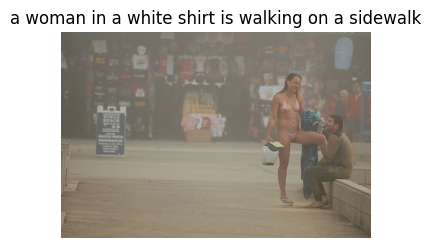

Image: 1784309115_0ad6791146.jpg
Generated: a woman in a white shirt is walking on a sidewalk
Human references:
- A girl in the bathing suit talking to a guy .
- A woman in a bikini is talking to a regularly dressed man on a bridge
- A woman in a small pink bikini chats on a cellphone while a man looks on outside a city shop .
- A woman in a string bathing suit with a man on a boardwalk on a foggy day .
- A woman in a pink bikini next to a man in brown .

--------------------------------------------------------------------------------



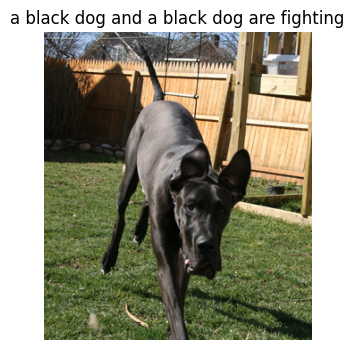

Image: 343218198_1ca90e0734.jpg
Generated: a black dog and a black dog are fighting
Human references:
- A black dog approaches the camera with his hind legs raised and his ears forward .
- A black dog in the backyard .
- A black dog running in a backyard
- A black dog running in a grassy fenced in yard .
- a black great Dane running toward the camera in a backyard

--------------------------------------------------------------------------------



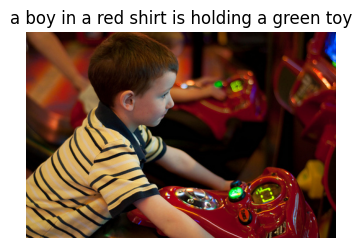

Image: 3666188047_e81e1d97a7.jpg
Generated: a boy in a red shirt is holding a green toy
Human references:
- A boy rides a game machine .
- A child in a yellow shirt is playing a red arcade ride .
- A child rides a mechanical ride .
- A small boy is playing a racing arcade game .
- a young man playing a motorcycle video game .

--------------------------------------------------------------------------------



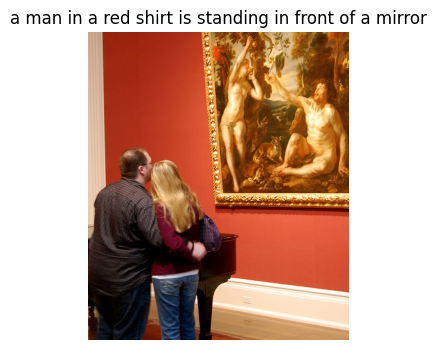

Image: 3371567346_b6522efdb8.jpg
Generated: a man in a red shirt is standing in front of a mirror
Human references:
- A couple look at some artwork .
- A couple stands near a piano and look up at a painting .
- A couple viewing a large painting hung on a red wall .
- a man and a woman are looking at a painting in a gallery .
- The man and woman look at a painting of naked people .

--------------------------------------------------------------------------------



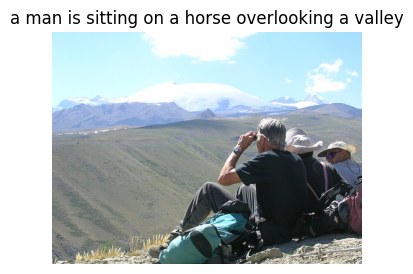

Image: 294549892_babb130543.jpg
Generated: a man is sitting on a horse overlooking a valley
Human references:
- 2 People with white hats looking over the mountain
- A group of people sit at the top of a cliff and look over the side .
- Three hikers are sitting on a mountainside looking at the view , one using a pair of binoculars .
- Three men sitting on a hill looking at the mountains and sky .
- Three people sit and look at mountains .

--------------------------------------------------------------------------------



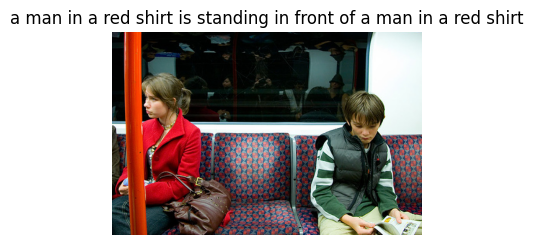

Image: 295729735_8360f2e64c.jpg
Generated: a man in a red shirt is standing in front of a man in a red shirt
Human references:
- A boy and woman sitting on a passenger train
- A woman and a boy sitting on a bus .
- People sitting on seats by orange pole
- Two people in a subway train separated by a seat
- Two people ride the train .

--------------------------------------------------------------------------------



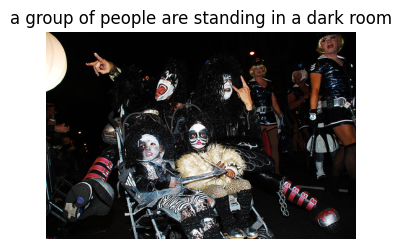

Image: 1812525037_528465037c.jpg
Generated: a group of people are standing in a dark room
Human references:
- The Kiss-costumed adults are pushing the strollers of the Kiss-costumed kids .
- The two young children are in black and white facepaint and costumes while riding in a stroller , they are being pushed by a man also in facepaint and a costume
- Two babies are dressed up as Kiss along with their parent 's .
- Two little kids in strollers have face makeup on like the band " Kiss " .
- Two parents with two children and others dressed up like the music group Kiss .

--------------------------------------------------------------------------------



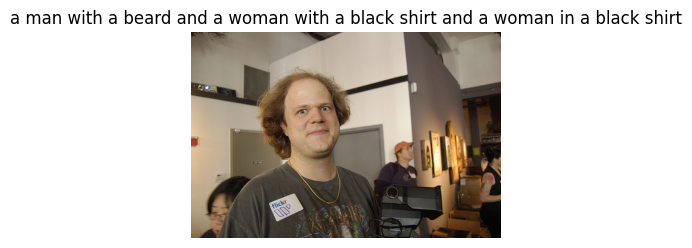

Image: 3532192208_64b069d05d.jpg
Generated: a man with a beard and a woman with a black shirt and a woman in a black shirt
Human references:
- A man in a room with three other people holding a large camera .
- A man is standing at the back of a room with a sticker on his shirt .
- Man with grey shirt with a white name badge .
- Red-headed man with " Flickr " badge at event .
- The man in the t-shirt , with a gold chain around his neck , is in a room with three others people .

--------------------------------------------------------------------------------



,image,generated_caption,reference_caption_1,reference_caption_2
0,1784309115_0ad6791146.jpg,a woman in a white shirt is walking on a sidewalk,A girl in the bathing suit talking to a guy .,A woman in a bikini is talking to a regularly ...
1,343218198_1ca90e0734.jpg,a black dog and a black dog are fighting,A black dog approaches the camera with his hin...,A black dog in the backyard .
2,3666188047_e81e1d97a7.jpg,a boy in a red shirt is holding a green toy,A boy rides a game machine .,A child in a yellow shirt is playing a red arc...
3,3371567346_b6522efdb8.jpg,a man in a red shirt is standing in front of a...,A couple look at some artwork .,A couple stands near a piano and look up at a ...
4,294549892_babb130543.jpg,a man is sitting on a horse overlooking a valley,2 People with white hats looking over the moun...,A group of people sit at the top of a cliff an...
5,295729735_8360f2e64c.jpg,a man in a red shirt is standing in front of a...,A boy and woman sitting on a passenger train,A woman and a boy sitting on a bus .
6,1812525037_528465037c.jpg,a group of people are standing in a dark room,The Kiss-costumed adults are pushing the strol...,The two young children are in black and white ...
7,3532192208_64b069d05d.jpg,a man with a beard and a woman with a black sh...,A man in a room with three other people holdin...,A man is standing at the back of a room with a...


In [8]:
def load_reference_captions():
    if TEST_SPLIT_PATH.exists():
        return pd.read_csv(TEST_SPLIT_PATH)
    if CAPTIONS_PATH.exists():
        return pd.read_csv(CAPTIONS_PATH)
    return None

refs_df = load_reference_captions()

if refs_df is not None and {'image', 'caption'}.issubset(refs_df.columns):
    candidate_images = [img for img in refs_df['image'].drop_duplicates().tolist() if (IMAGE_DIR / img).exists()]
else:
    candidate_images = [p.name for p in IMAGE_DIR.glob('*.jpg')]

if len(candidate_images) == 0:
    raise RuntimeError('No images found for inference demo.')

rng = np.random.default_rng(42)
sample_images = rng.choice(candidate_images, size=min(8, len(candidate_images)), replace=False).tolist()

results = []
for image_name in sample_images:
    image_path = IMAGE_DIR / image_name
    pred = generate_caption(str(image_path), caption_system)
    references = []
    if refs_df is not None and 'image' in refs_df.columns:
        references = refs_df[refs_df['image'] == image_name]['caption'].tolist()[:5]

    results.append({
        'image': image_name,
        'generated_caption': pred,
        'reference_caption_1': references[0] if len(references) > 0 else '',
        'reference_caption_2': references[1] if len(references) > 1 else '',
    })

    img = Image.open(image_path).convert('RGB')
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(pred)
    plt.show()

    print('Image:', image_name)
    print('Generated:', pred)
    if references:
        print('Human references:')
        for r in references:
            print('-', r)
    print('\n' + '-' * 80 + '\n')

results_df = pd.DataFrame(results)
display(results_df)